Name : Vishesh Kumar 
Cu24250050    sec: B , rollno : 69  
Experiment-2  , Labsheet -2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

file_path = "/workspaces/-Mastery_in_Data-Analytics_and_Visualizations_and_Career-Advancement/WA_Fn-UseC_-HR-Employee-Attrition-selected-columns.csv"

df = pd.read_csv(file_path)

print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  
0                 1          2  Life Sciences              1               1  
1                 8          1  Life Sciences              1               2  
2                 2          2          Other              1               4  
3                 3          4  Life Sciences              1               5  
4                 2          1        Medical              1               7  


In [3]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe(include="all"))

Shape of Dataset: (1470, 10)

Column Names:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber'],
      dtype='str')

Data Types:
Age                 int64
Attrition             str
BusinessTravel        str
DailyRate           int64
Department            str
DistanceFromHome    int64
Education           int64
EducationField        str
EmployeeCount       int64
EmployeeNumber      int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1470 non-null   int64
 1   Attrition         1470 non-null   str  
 2   BusinessTravel    1470 non-null   str  
 3   DailyRate         1470 non-null   int64
 4   Department        1470 non-null   str  
 5   DistanceFromHome  1470 non-null   int64

In [4]:
for column in df.columns:
    print("\n", column)
    print(df[column].value_counts().head(10))


 Age
Age
35    78
34    77
36    69
31    69
29    68
32    61
30    60
33    58
38    58
40    57
Name: count, dtype: int64

 Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

 BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

 DailyRate
DailyRate
691     6
408     5
1082    5
530     5
1329    5
329     5
334     4
1125    4
427     4
1225    4
Name: count, dtype: int64

 Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

 DistanceFromHome
DistanceFromHome
2     211
1     208
10     86
9      85
3      84
7      84
8      80
5      65
4      64
6      59
Name: count, dtype: int64

 Education
Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64

 EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree   

In [5]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber'],
      dtype='str')


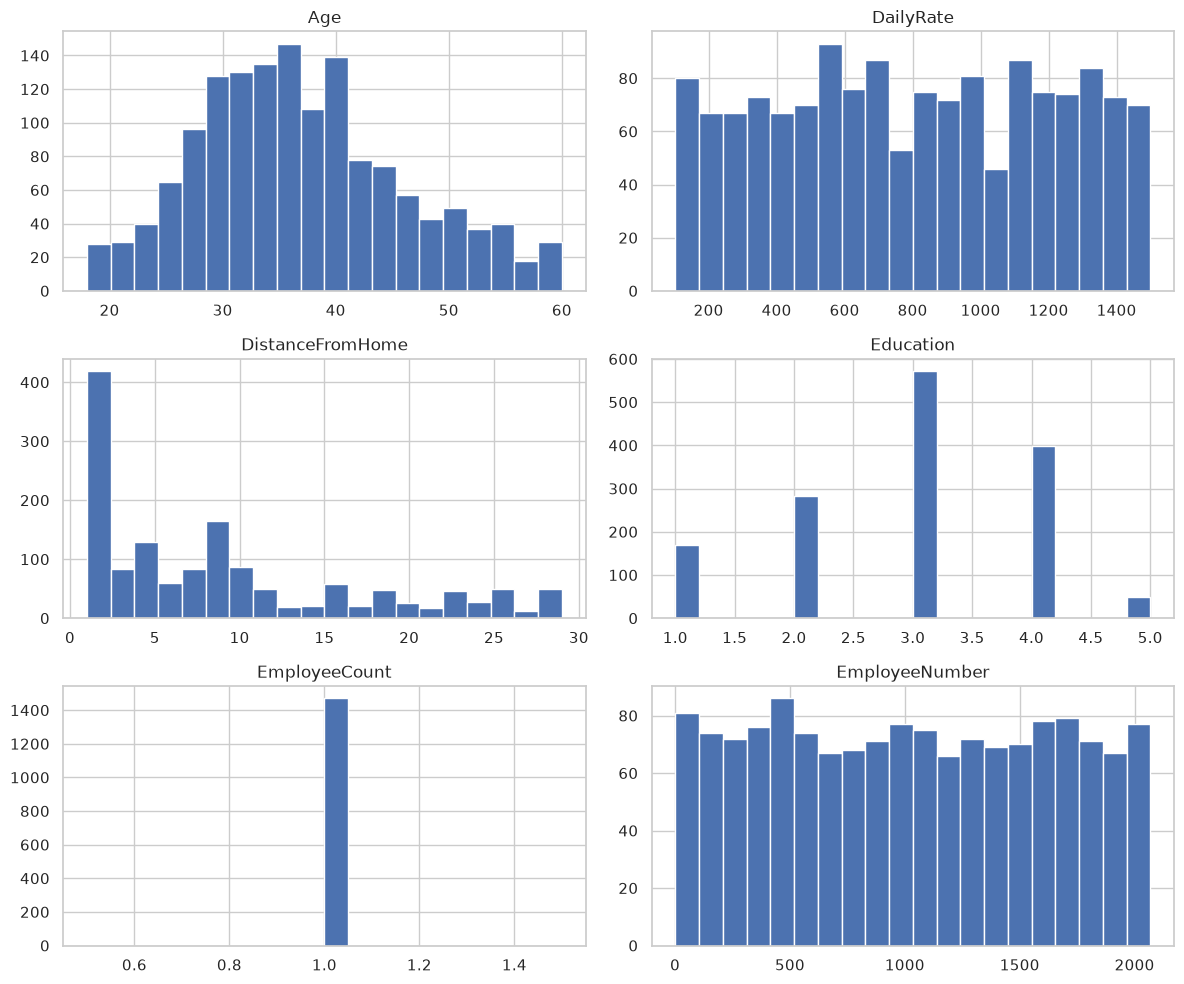

In [6]:
df[numerical_columns].hist(
    figsize=(12, 10),
    bins=20
)

plt.tight_layout()
plt.show()

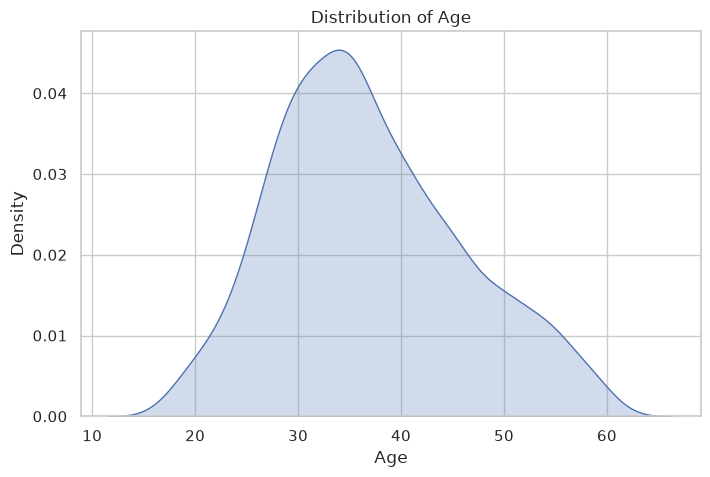

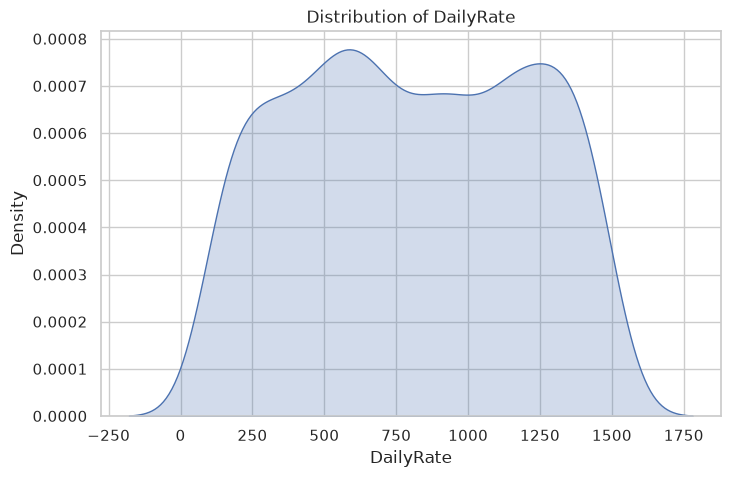

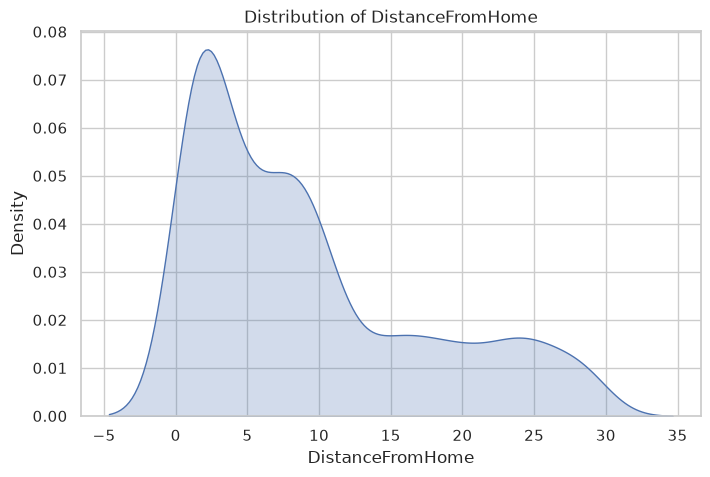

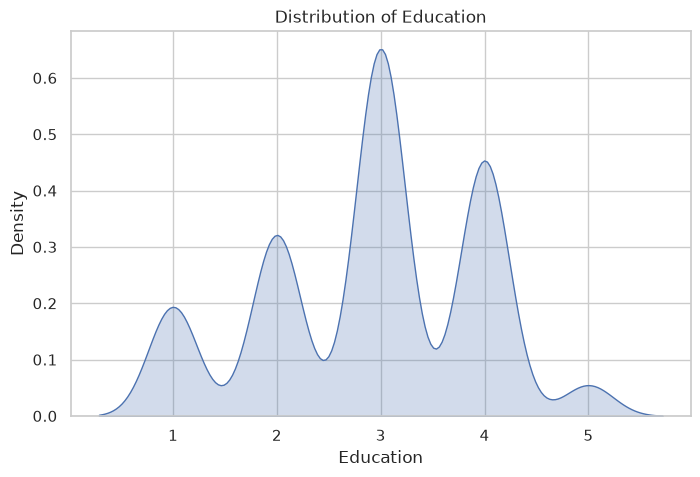

/tmp/ipykernel_5373/2863598134.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, fill=True)


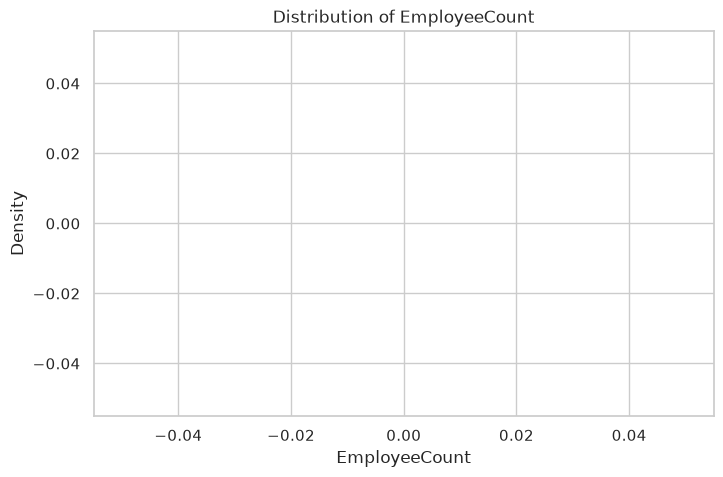

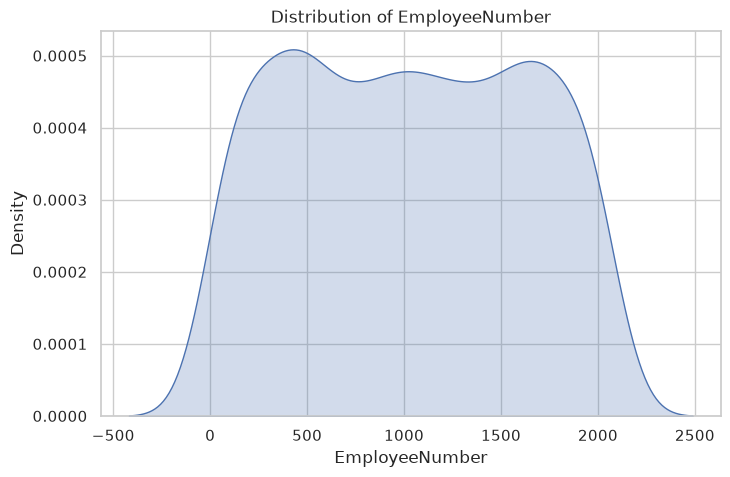

In [7]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=column, fill=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.show()

In [9]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField'], dtype='str')


/tmp/ipykernel_5373/1130369359.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


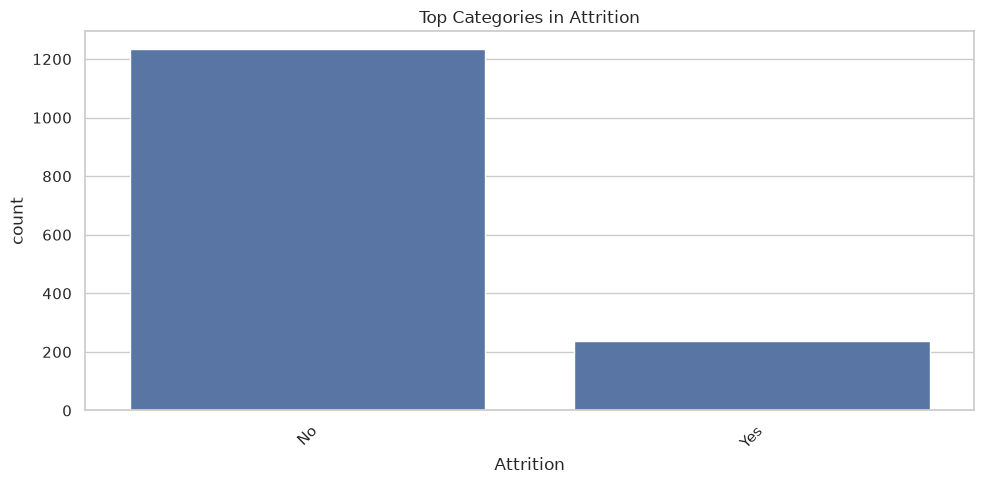

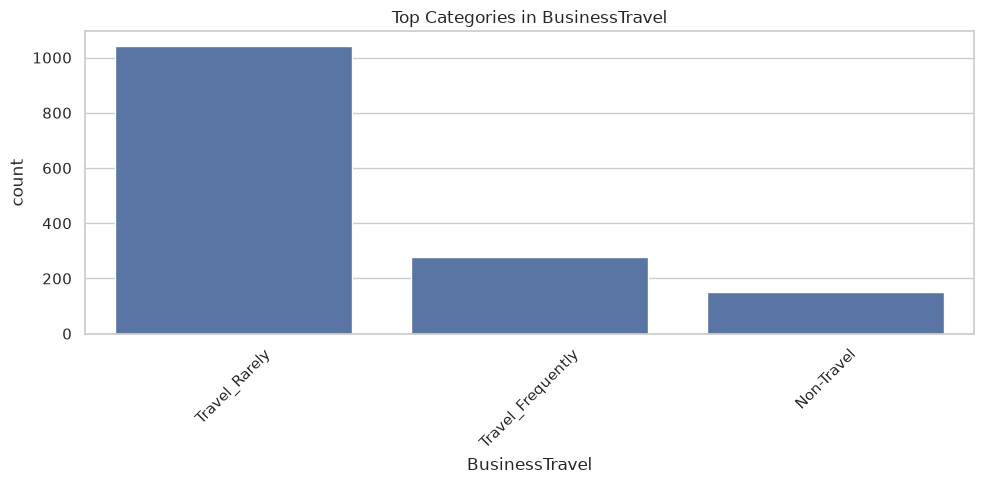

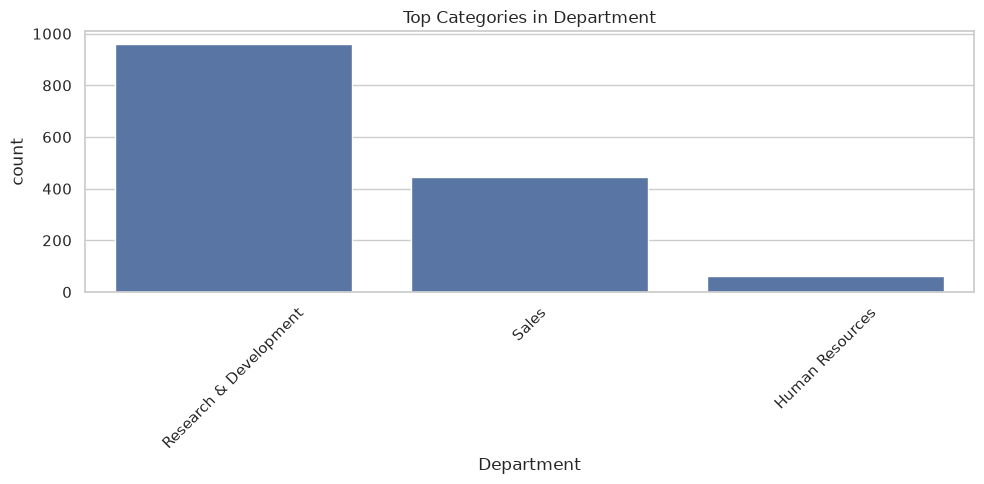

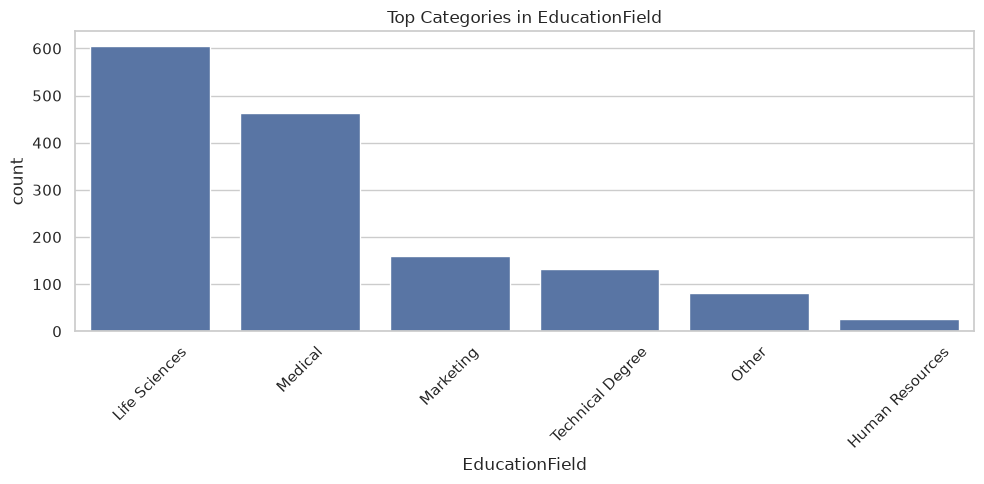

In [10]:
for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().head(10).index
    )
    
    plt.title(f"Top Categories in {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [11]:
correlation = df[numerical_columns].corr()

print(correlation)

                       Age  DailyRate  DistanceFromHome  Education  \
Age               1.000000   0.010661         -0.001686   0.208034   
DailyRate         0.010661   1.000000         -0.004985  -0.016806   
DistanceFromHome -0.001686  -0.004985          1.000000   0.021042   
Education         0.208034  -0.016806          0.021042   1.000000   
EmployeeCount          NaN        NaN               NaN        NaN   
EmployeeNumber   -0.010145  -0.050990          0.032916   0.042070   

                  EmployeeCount  EmployeeNumber  
Age                         NaN       -0.010145  
DailyRate                   NaN       -0.050990  
DistanceFromHome            NaN        0.032916  
Education                   NaN        0.042070  
EmployeeCount               NaN             NaN  
EmployeeNumber              NaN        1.000000  


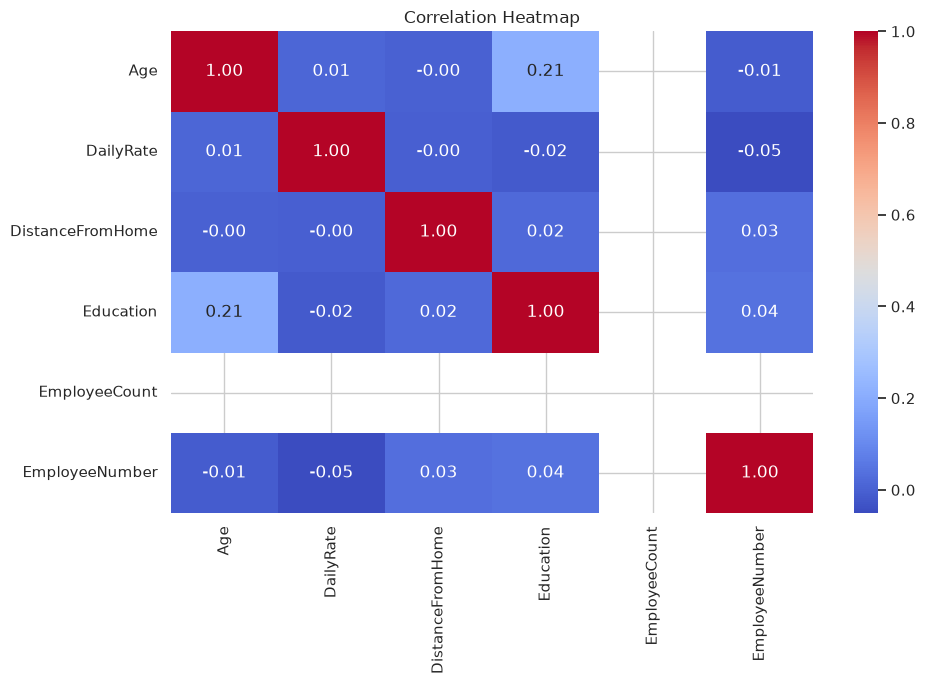

In [12]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

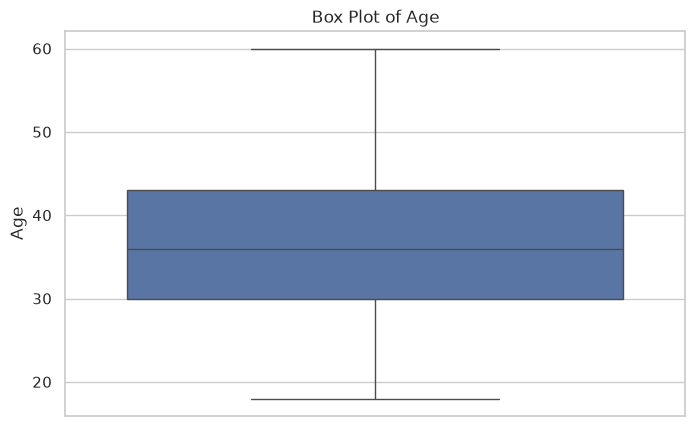

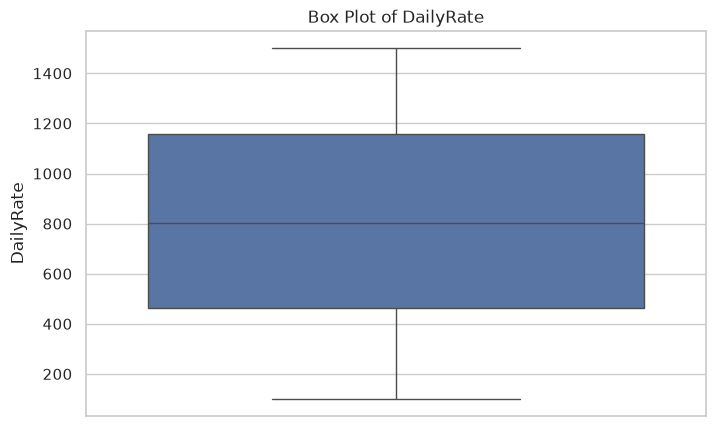

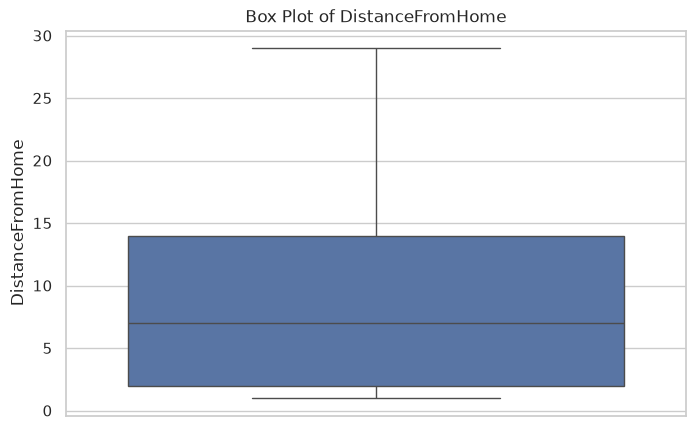

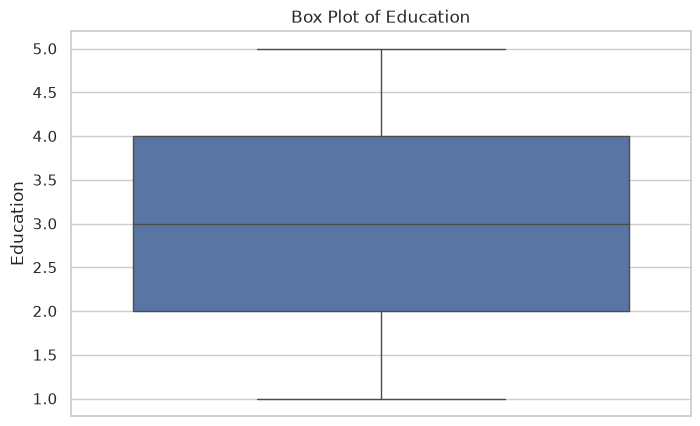

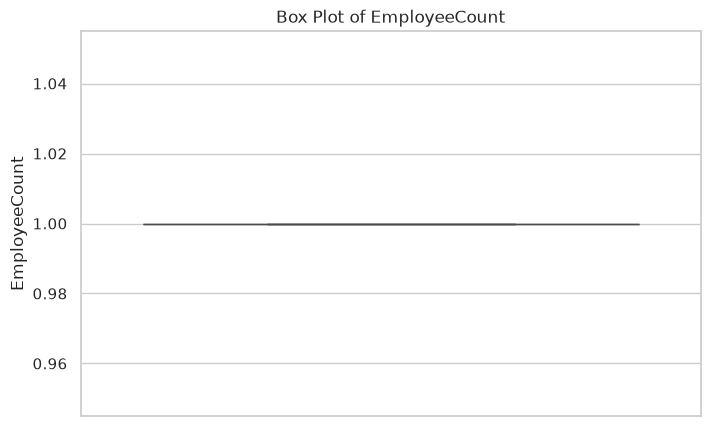

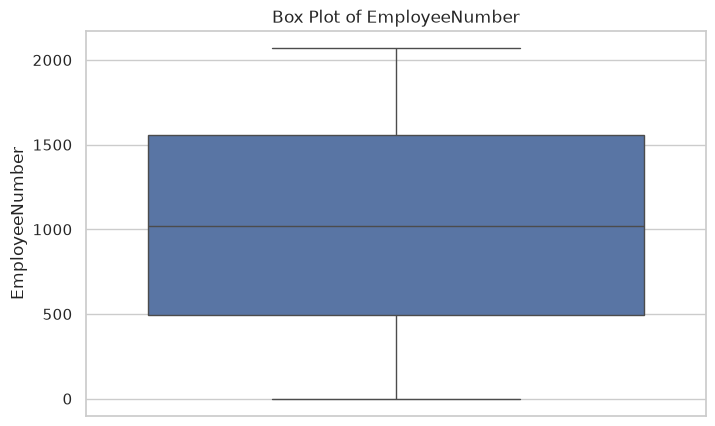

In [13]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(data=df, y=column)
    
    plt.title(f"Box Plot of {column}")
    plt.show()

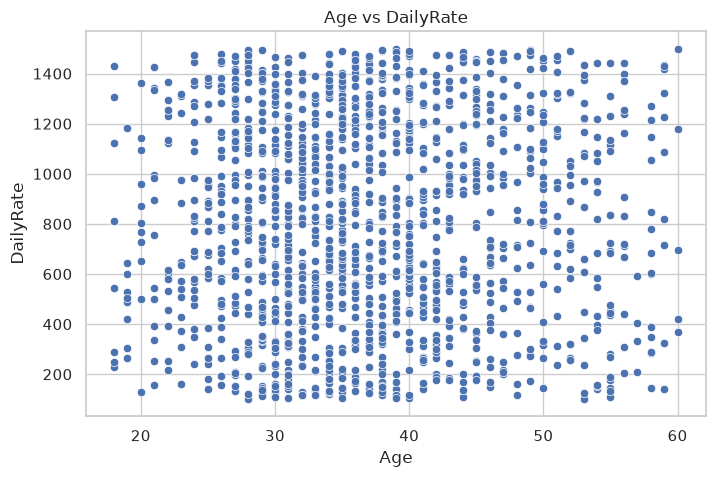

In [14]:
if len(numerical_columns) >= 2:
    
    x = numerical_columns[0]
    y = numerical_columns[1]
    
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df,
        x=x,
        y=y
    )
    
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

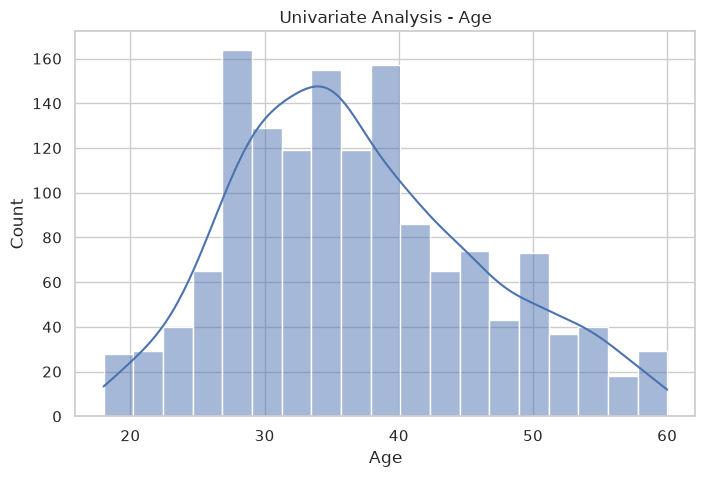

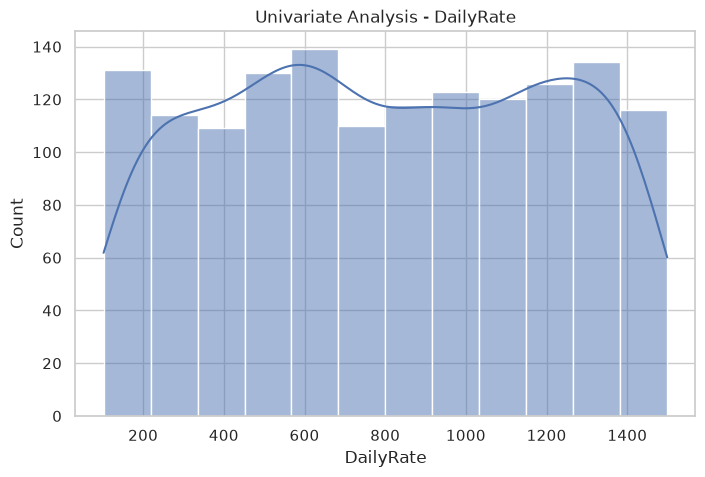

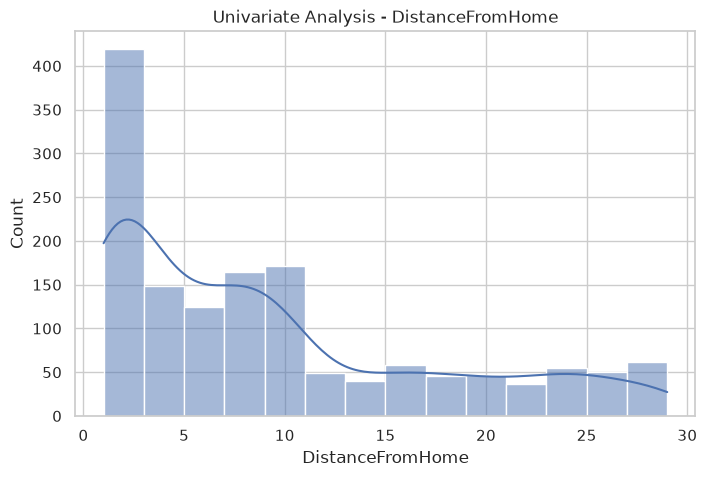

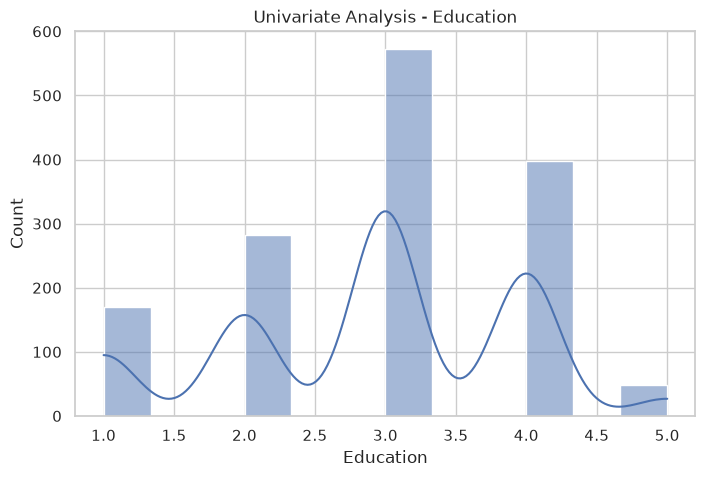

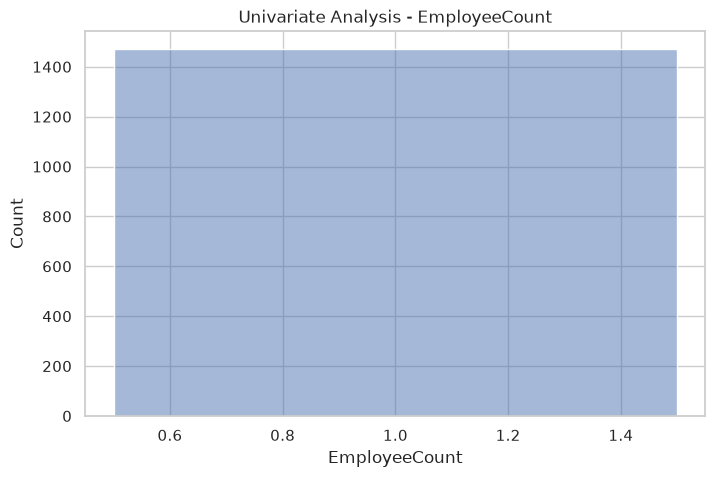

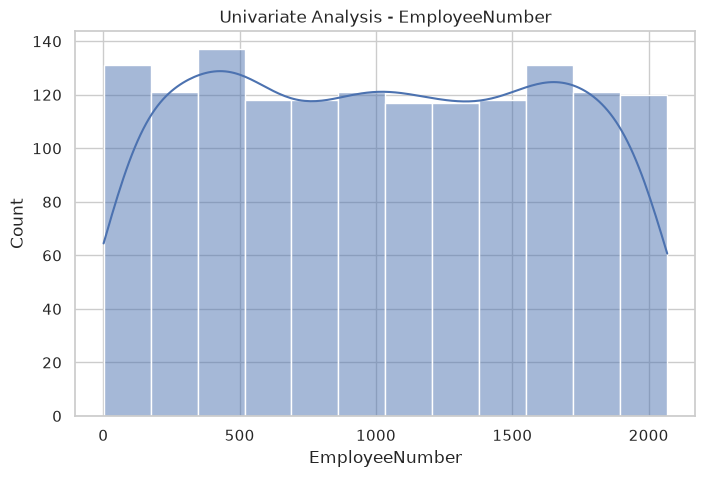

In [15]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Univariate Analysis - {column}")
    plt.show()

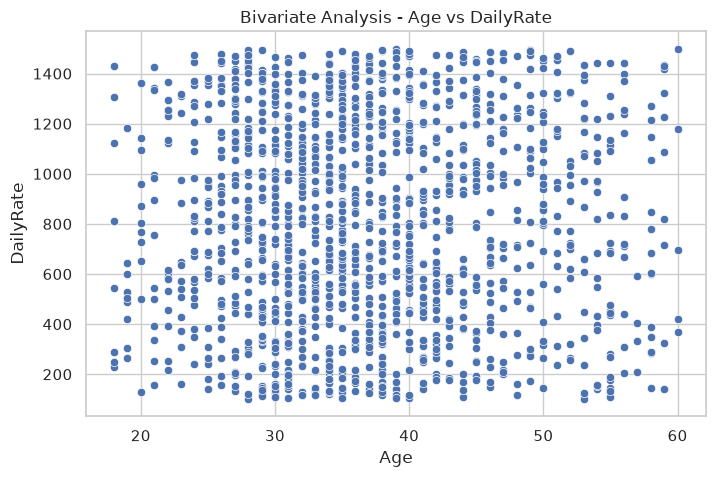

In [16]:
if len(numerical_columns) >= 2:
    
    x = numerical_columns[0]
    y = numerical_columns[1]
    
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df,
        x=x,
        y=y
    )
    
    plt.title(f"Bivariate Analysis - {x} vs {y}")
    plt.show()

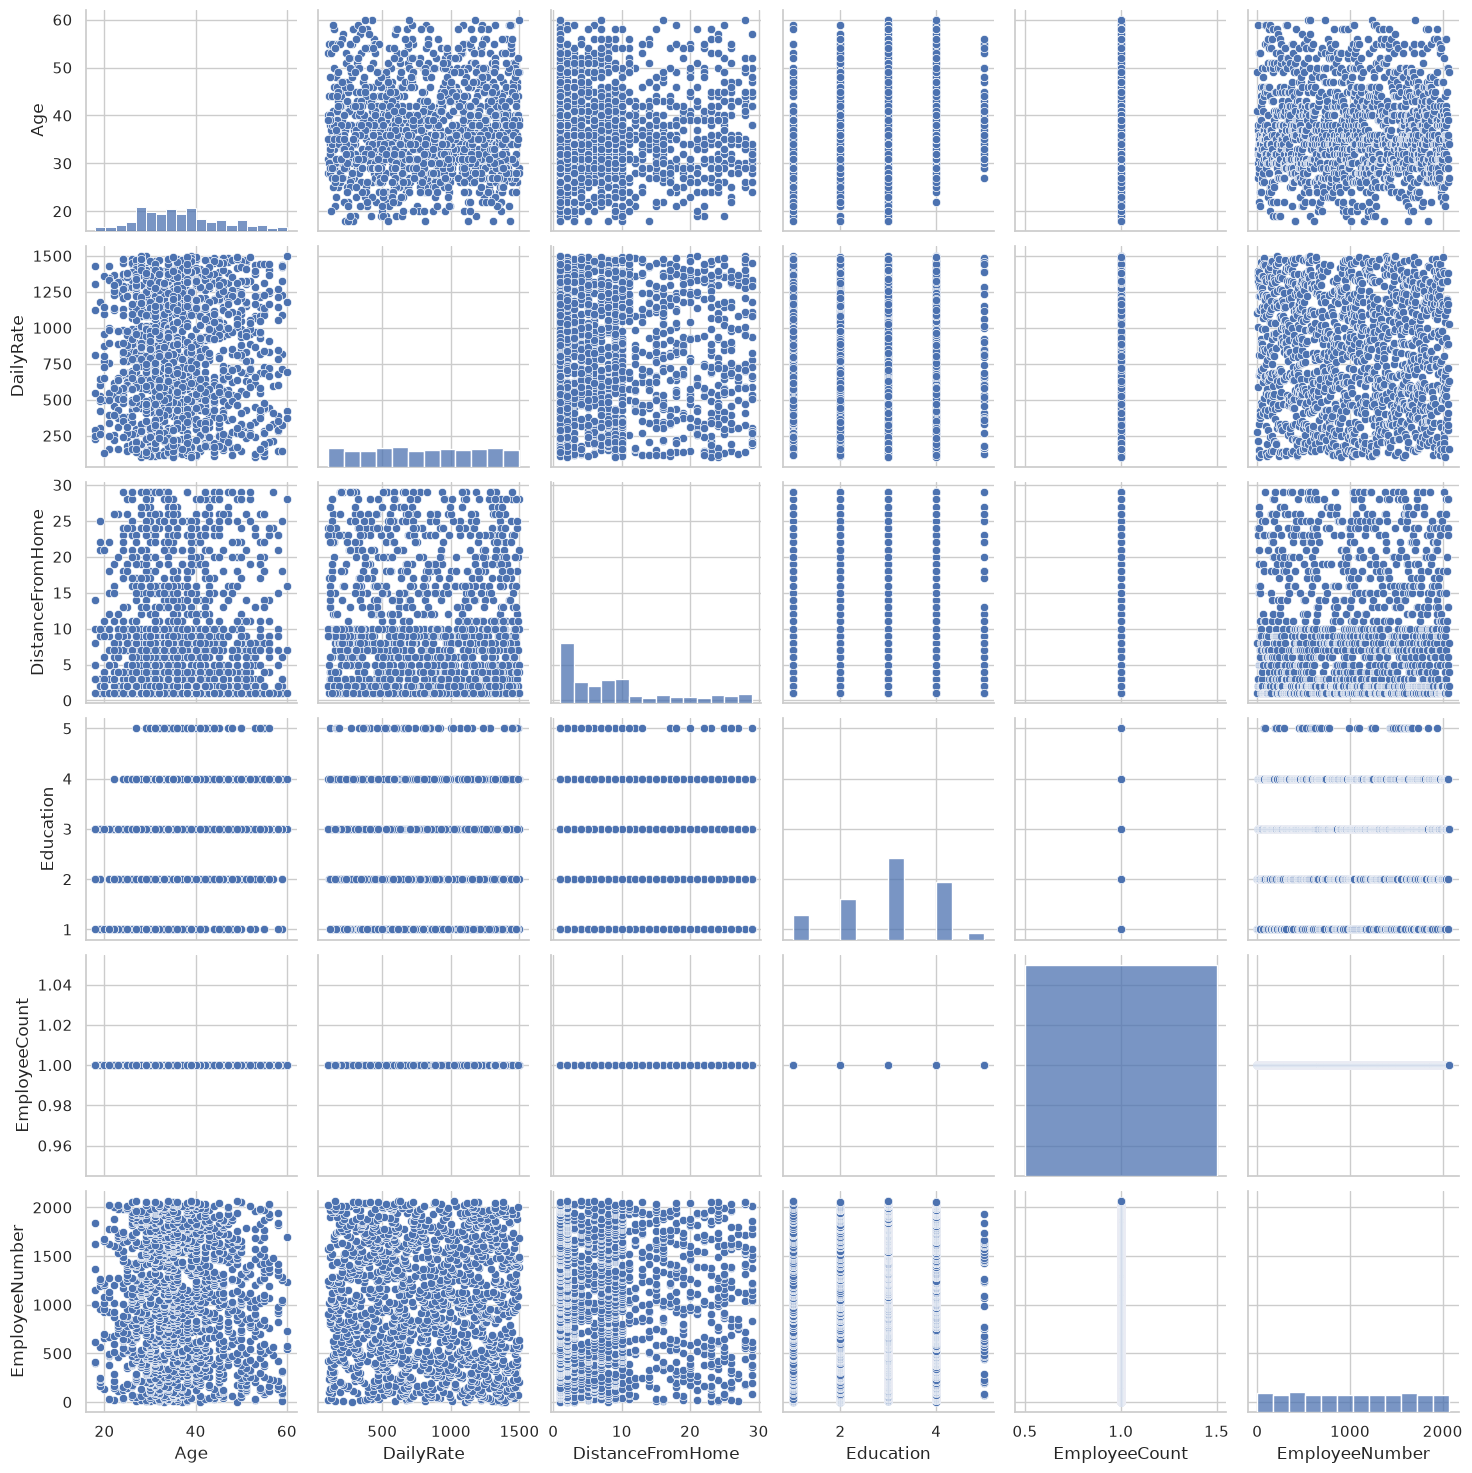

In [17]:
if len(numerical_columns) >= 3:
    
    sns.pairplot(
        df[numerical_columns].dropna()
    )
    
    plt.show()

In [18]:
correlation_matrix = df[numerical_columns].corr()

print("Correlation with numerical variables:")
print(correlation_matrix)

Correlation with numerical variables:
                       Age  DailyRate  DistanceFromHome  Education  \
Age               1.000000   0.010661         -0.001686   0.208034   
DailyRate         0.010661   1.000000         -0.004985  -0.016806   
DistanceFromHome -0.001686  -0.004985          1.000000   0.021042   
Education         0.208034  -0.016806          0.021042   1.000000   
EmployeeCount          NaN        NaN               NaN        NaN   
EmployeeNumber   -0.010145  -0.050990          0.032916   0.042070   

                  EmployeeCount  EmployeeNumber  
Age                         NaN       -0.010145  
DailyRate                   NaN       -0.050990  
DistanceFromHome            NaN        0.032916  
Education                   NaN        0.042070  
EmployeeCount               NaN             NaN  
EmployeeNumber              NaN        1.000000  


In [19]:
for column in correlation_matrix.columns:
    for row in correlation_matrix.index:
        
        if column != row:
            value = correlation_matrix.loc[row, column]
            
            if abs(value) >= 0.7:
                print(
                    f"{row} and {column}: "
                    f"Correlation = {value:.2f}"
                )

In [20]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64


In [21]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
Age                 0.0
Attrition           0.0
BusinessTravel      0.0
DailyRate           0.0
Department          0.0
DistanceFromHome    0.0
Education           0.0
EducationField      0.0
EmployeeCount       0.0
EmployeeNumber      0.0
dtype: float64


In [ ]:
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
0


In [ ]:
print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset Information:")
df.info()


Final Dataset Shape:
(1470, 10)

Final Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1470 non-null   int64
 1   Attrition         1470 non-null   str  
 2   BusinessTravel    1470 non-null   str  
 3   DailyRate         1470 non-null   int64
 4   Department        1470 non-null   str  
 5   DistanceFromHome  1470 non-null   int64
 6   Education         1470 non-null   int64
 7   EducationField    1470 non-null   str  
 8   EmployeeCount     1470 non-null   int64
 9   EmployeeNumber    1470 non-null   int64
dtypes: int64(6), str(4)
memory usage: 115.0 KB
